## mnist_explore.ipynb
Download MNIST handwritten digit data and start exploring...

In [2]:
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (1.5, 1.5)
#import sys
#print(sys.executable) # check correct .venv?

x_train.shape: (60000, 28, 28)     y_train.shape: (60000,)
x_test.shape : (10000, 28, 28)      y_test.shape: (10000,)
x_train.dtype: uint8     x_train.dtype: uint8


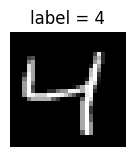

In [3]:
# load data using keras
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# check the shape of arrays
print('x_train.shape:', x_train.shape, '    y_train.shape:', y_train.shape)
print('x_test.shape :', x_test.shape, '     y_test.shape:', y_test.shape)
print('x_train.dtype:', x_train.dtype, '    x_train.dtype:', y_train.dtype)

# show one item
def draw_1_OLD(imgs, labels, index):
    plt.imshow(imgs[index], cmap="gray")
    plt.title(f"label = {labels[index]}")
    plt.axis("off")
    plt.show()
draw_1_OLD(x_train, y_train, 2)

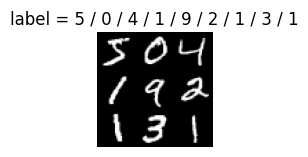

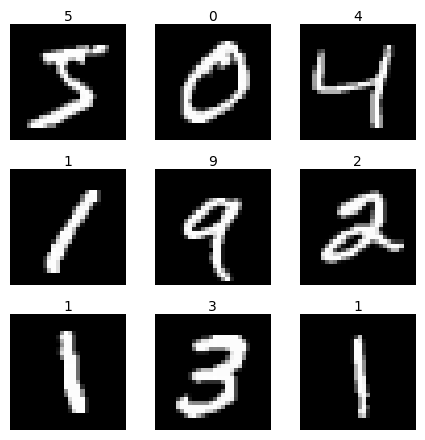

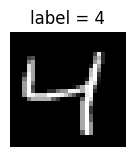

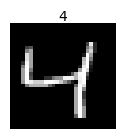

In [4]:
def draw_grid_pixels(imgs : np.ndarray, labels, i : np.ndarray, shape=None):
    pxrow, pxcol = len(imgs[0]), len(imgs[0][0])
    pixels = np.zeros((shape[0] * pxrow, shape[1] * pxcol), dtype=imgs.dtype)

    index = 0
    for r in range(shape[0]):
        for c in range(shape[1]):
            pixels[r*pxrow:(r+1)*pxrow, c*pxcol:(c+1)*pxcol] = imgs[i[index]]
            index += 1
            if index >= len(i): break

    plt.imshow(pixels, cmap="gray")
    plt.title(f"label = " + ' / '.join(str(labels[x]) for x in i))
    plt.axis("off")
    plt.show()



def draw_grid(imgs: np.ndarray, labels, indices: np.ndarray, shape: tuple[int, int]):
    rows, cols = shape
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))

    # make axes always iterable, even for 1x1
    axes = np.array(axes).reshape(rows, cols)

    index_pos = 0
    for r in range(rows):
        for c in range(cols):
            ax = axes[r, c]

            if index_pos < len(indices):
                idx = indices[index_pos]
                ax.imshow(imgs[idx], cmap="gray")
                ax.set_title(str(labels[idx]), fontsize=10, pad=2)
                index_pos += 1
            else:
                # blank unused subplot if grid is larger than number of images
                ax.axis("off")
                continue

            ax.axis("off")

    plt.tight_layout()
    plt.show()

draw_grid_pixels(x_train, y_train, np.array(list(range(9))), (3,3))
draw_grid(x_train, y_train, np.array(list(range(9))), (3,3))

def draw_1_pixels(imgs, labels, index):
    draw_grid_pixels(imgs, labels, np.array([index]), (1,1))

def draw_1(imgs, labels, index):
    draw_grid(imgs, labels, np.array([index]), (1, 1))

draw_1_pixels(x_train, y_train, 2)
draw_1(x_train, y_train, 2)

In [74]:
# thinking about to structure a NN layer class?
RNG = np.random.default_rng(seed=42)
ACTIVATION_ReLU = 'ReLU'
ACTIVATION_None = None
class Model:
    def __init__(self, n_input, n_outputs: list, output_activation=ACTIVATION_None):
        assert len(n_outputs) > 0
        self.layers = []
        in_out = [n_input]
        in_out.extend(n_outputs)
        for i in range(len(n_outputs)):
            parent = None if i == 0 else self.layers[i - 1]
            self.layers.append( Layer(in_out[i], in_out[i+1], ACTIVATION_ReLU, parent) )
        for i in range(len(self.layers)-1):
            self.layers[i].childLayer = self.layers[i+1]
        self.inputLayer = self.layers[0]
        self.outputLayer = self.layers[-1]
        # amend output layer activation function
        self.outputLayer.AF = output_activation

    def forward_pass(self, x: np.ndarray):
        return self.inputLayer(x) # Layer.__call__() recurses through layers

    def backward_pass(self, deriv0):
        # back prop from last layer (NOT IMPLEMENTED YET)
        self.outputLayer.backprop(deriv0)

    def epoch(self, x_in: np.ndarray, y_target: np.ndarray, learning_rate=0.01):
        assert x_in.shape[0] == y_target.shape[0] # check number of X matches Y
        y_pred = np.zeros(y_target.shape, dtype=np.float64)
        self.SSE, self.MSE = 0.0, 0.0

        # reset all derivs
        for L in self.layers: L.derivs.fill(0.0)

        for i in range(len(x_in)):
            y_pred[i] = self.forward_pass(x_in[i])
            resid = y_pred[i] - y_target[i] # vector of residuals
            self.backward_pass(2.0 * resid / y_target.size) # deriv of mean squared residuals
            self.SSE += np.sum(resid**2) # running total of SSE
        self.MSE = self.SSE / y_target.size # mean of SSE 

        self.update_params(learning_rate)

        return y_pred
    
    def fit(self, x_in: np.ndarray, y_target: np.ndarray, max_epochs=100, learning_rate=0.01):
        MSE_curve = np.zeros(max_epochs)
        for i in range(max_epochs):
            ypred = self.epoch(x_in, y_target, learning_rate)
            MSE_curve[i] = self.MSE
            if i % 10 == 0:
                print(f"Epoch: {i:05d} --- ", f"MSE: {self.MSE:.5f} --- ", [f"{y[0]:.3f}" for y in ypred])
        return ypred
    
    def update_params(self, learning_rate=0.01):
        # update parameters
        for L in self.layers:
            L.params -= learning_rate * L.derivs

class Layer:
    """ a layer of neurons """

    # todo: pack weights, biases into one data structure?
    # also: similar for gradients?

    def __init__(self, n_input, n_output, activation_func=ACTIVATION_ReLU, parentLayer=None, childLayer=None):
        self.params = RNG.uniform(-1, 1, (n_output, n_input+1))
        self.derivs = np.zeros((n_output, n_input+1))
        self.mx_weights = self.params[:, :-1]
        self.vec_biases = self.params[:, -1]
        self.vec_input = None # store last used input to __call__()
        self.vec_pre_activations = np.zeros(n_output)
        self.vec_activations = np.zeros(n_output)
        self.AF = activation_func
        self.parentLayer = parentLayer
        self.childLayer = childLayer

        # allocate buffers/views for use in backprop()
        self._local_derivs = np.zeros_like(self.derivs)
        self._local_derivs_dX_dw = self._local_derivs[:, :-1]
        self._local_derivs_dX_db = self._local_derivs[:, -1]

        self._final_derivs_dL_dp = np.zeros_like(self.derivs)
        self._final_derivs_dL_dw = self._final_derivs_dL_dp[:, :-1]
        self._final_derivs_dL_db = self._final_derivs_dL_dp[:, -1]
        
        self._upstream_dL_dz = np.zeros(n_output)
        self._parent_deriv = np.zeros(n_input)

    def __call__(self, vec_x):
        # - take array of inputs
        # - apply weights/biases/activation function
        # - return array of outputs
        self.vec_input = vec_x
        
        np.dot(self.mx_weights, vec_x, out=self.vec_pre_activations) # z = Wx + b
        self.vec_pre_activations += self.vec_biases
        if self.AF == ACTIVATION_ReLU:
            np.maximum(self.vec_pre_activations, 0, out=self.vec_activations)
        else:
            # no activation function
            self.vec_activations[:] = self.vec_pre_activations

        if self.childLayer is None:
            return self.vec_activations
        else:
            return self.childLayer(self.vec_activations)
    
    def backprop(self, upstream_deriv):
        p = self.parentLayer
        # upstream_deriv: 
        # - is a vector, length equal to no. of outputs of THIS layer
        # - (equal to the number of ROWS in the weights matrix for THIS layer)
        # - contains derivatives of the loss wrt THIS layer's outputs (activations)
        # - (dL/da_1, dL/da_2, ..., dL/da_n)

        # (oversimplified!) 1-neuron-per-layer example looks like:
        # upstream derivative = upstream(layer) = W(layer+1) * W(layer+2) * ... * W(layer n)
        # dL/dW(layer) = [local deriv = X(layer)] * upstream(layer)
        # dL/db(layer) = [local deriv = 1.0] * upstream(layer)

        # step 0. transform upstream_derivs from dL/da to dL/dz (wrt pre-activations)
        # - dL/dz = dL/da * da/dz
        # - da/dz (ReLU): 0 (if z <= 0), 1 (otherwise)
        # - da/dz (None): 1
        if self.AF == ACTIVATION_ReLU:
            self._upstream_dL_dz[:] = upstream_deriv * (self.vec_pre_activations > 0)
        else:
            self._upstream_dL_dz[:] = upstream_deriv

        # !!! remember [W b] structure !!! (use views)
        # step 1. calculate, local_derivs for weights matrix
        # each column populated with input x: x_1, x_2, ..., x_n
        # (No longer needed, just need _final_derivs..., leaving for posterity)
        self._local_derivs_dX_dw[:] = self.vec_input

        # step 2. calculate, local_derivs for bias vector (final column)
        # (No longer needed, just need _final_derivs..., leaving for posterity)
        self._local_derivs_dX_db.fill(1.0)

        # step 3. "multiply" by the upstream derivs to get final derivs wrt loss
        # - we need to scale each row of the local derivs by the corresponding element of the upstream derivs
        # - this operation is the outer product
        # - for biases, the local deriv is 1, so the final column equals the upstream derivs
        self._final_derivs_dL_dw[:] = np.outer(self._upstream_dL_dz, self.vec_input)
        self._final_derivs_dL_db[:] = self._upstream_dL_dz

        # step 4. ACCUMULATE derivs from step 3 into self.derivs
        self.derivs += self._final_derivs_dL_dp

        # step 5. prepare parent_deriv to continue backprop to parent
        # - becomes the new upstream_deriv for the next layer in backpropagation
        # - is a vector, length equal to no. of inputs of THIS layer, OR
        # - is a vector, length equal to no. of outputs of PARENT layer
        # - contains derivatives of the loss wrt PARENT layer's outputs (activations), OR
        # - contains derivatives of the loss wrt THIS layer's inputs
        # - (dL/da_1, dL/da_2, ..., dL/da_n)
        if p is not None: 
            self._parent_deriv.fill(0)
            # calculate the weighted sum over the rows of the weights matrix, with each row scaled by dL/dz
            # ( dL/da(in) = dz(out)/da(in) * dL/dz(out) )
            # dz(out)/da(in): derivatives wrt inputs leaves the weights (z = a1w1 + a2w2 + ... + b)
            # dL/dz(out): computed above in self._upstream_dL_dz
            """ (explicit version for reference)
            rows, cols = self.mx_weights.shape
            for i in range(rows):
                for j in range(cols):
                self._parent_deriv[j] += self.mx_weights[i][j] * self._upstream_dL_dz[i]
            """
            self._parent_deriv[:] = self.mx_weights.T @ self._upstream_dL_dz
            p.backprop(self._parent_deriv) # if has parent, keep backprop'ing


def test_Layer():
    l = Layer(3, 2)
    x = np.array([1.0, 2.0, 3.0])
    l(x)
    print(l.mx_weights)
    print(l.vec_biases)
    print(l.vec_activations)

def test_Model():
    M = Model(3, [4, 4, 1])

    xs = np.array([
        [2.0, 3.0, -1.0],
        [3.0, -1.0, 0.5],
        [0.5, 1.0, 1.0],
        [1.0, 1.0, -1.0]
    ])

    ys = np.array([[1.0], [-1.0], [-1.0], [1.0]])

    #for i in range(100):
    #    ypred = M.epoch(xs, ys, learning_rate=0.094)
    #    if i % 10 == 0:
    #        print(f"{i:05d} --- ", f"MSE: {M.MSE:.5f} --- ", [f"{y[0]:.3f}" for y in ypred])

    M.fit(xs, ys, learning_rate=0.094)

test_Model()

Epoch: 00000 ---  MSE: 1.48253 ---  ['-0.236', '-0.298', '-0.161', '-0.791']
Epoch: 00010 ---  MSE: 0.44310 ---  ['0.956', '-1.020', '0.092', '0.240']
Epoch: 00020 ---  MSE: 0.24566 ---  ['1.228', '-1.042', '-0.212', '0.445']
Epoch: 00030 ---  MSE: 0.16377 ---  ['1.232', '-1.039', '-0.387', '0.526']
Epoch: 00040 ---  MSE: 0.10074 ---  ['1.205', '-1.041', '-0.525', '0.634']
Epoch: 00050 ---  MSE: 0.05252 ---  ['1.181', '-1.028', '-0.638', '0.786']
Epoch: 00060 ---  MSE: 0.02495 ---  ['1.139', '-1.022', '-0.731', '0.913']
Epoch: 00070 ---  MSE: 0.01064 ---  ['1.063', '-1.019', '-0.809', '0.956']
Epoch: 00080 ---  MSE: 0.00524 ---  ['1.051', '-1.017', '-0.865', '0.994']
Epoch: 00090 ---  MSE: 0.00238 ---  ['1.029', '-1.009', '-0.907', '1.001']
